In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

from mtotosalama.ingestion.boundaries import load_kenya_county_boundaries
from mtotosalama.ingestion.facilities import load_health_facilities_for_county

PROJECT_ROOT = Path.cwd().parent  # notebook runs from notebooks/, project root is one level up
GADM_PATH = PROJECT_ROOT / "data" / "raw" / "gadm41_KEN.gpkg"

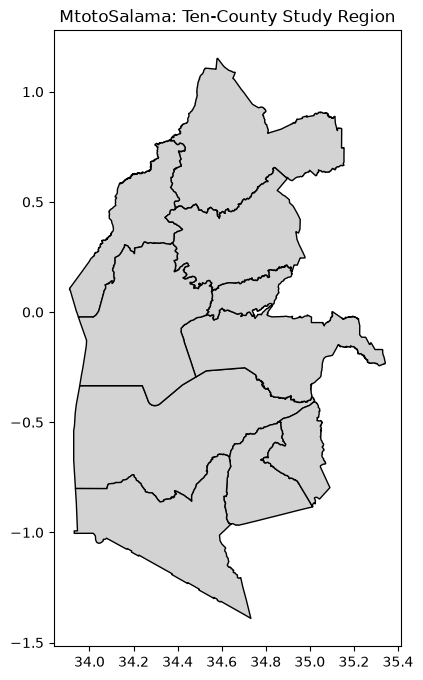

In [2]:
counties = load_kenya_county_boundaries(GADM_PATH)
counties.plot(figsize=(8, 8), edgecolor="black", facecolor="lightgrey")
plt.title("MtotoSalama: Ten-County Study Region")
plt.show()

In [3]:
kisumu_facilities = load_health_facilities_for_county("Kisumu")
print(f"Facilities found in Kisumu: {len(kisumu_facilities)}")
kisumu_facilities.head()

Facilities found in Kisumu: 154


,element,id,geometry,amenity,healthcare,name,condition,operational_status,operational_status:availability,operator:description,...,healthcare:speciality,addr:street,old_name,operator:wikidata,short_name,addr:city,operator:website,source,type,county_name
0,node,3294340548,POINT (34.75678 -0.11963),pharmacy,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kisumu
1,node,4599996001,POINT (34.61079 -0.0014),clinic,NaN,University Clinic,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kisumu
2,node,8190794363,POINT (34.7656 -0.09793),clinic,NaN,Joy Pediatric Medical Centre,unknown,operational,always,private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kisumu
3,node,8190812612,POINT (34.76471 -0.09692),hospital,NaN,Star Hospital,unknown,operational,always,private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kisumu
4,node,8190815124,POINT (34.7655 -0.09795),clinic,NaN,Medafya Health Care,unknown,operational,always,private,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kisumu


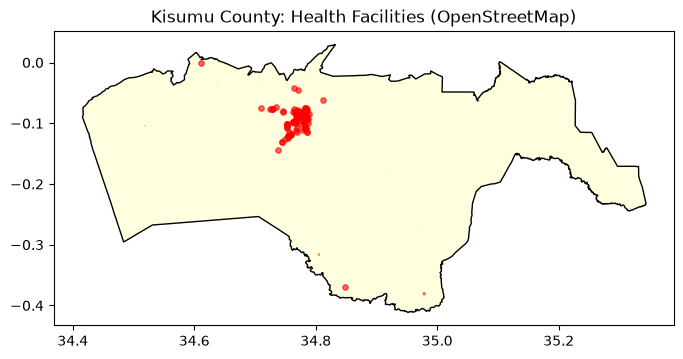

In [4]:
kisumu_boundary = counties[counties["county_name"] == "Kisumu"]

fig, ax = plt.subplots(figsize=(8, 8))
kisumu_boundary.plot(ax=ax, edgecolor="black", facecolor="lightyellow")
kisumu_facilities.plot(ax=ax, color="red", markersize=15, alpha=0.6)
plt.title("Kisumu County: Health Facilities (OpenStreetMap)")
plt.show()